In [2]:
import tmm

from numpy import pi, linspace, inf, array
import numpy as np
import math
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.signal import hilbert
import matplotlib.pyplot as plt
%matplotlib inline

degree = pi/180

(395,)
(394,)
(394,)


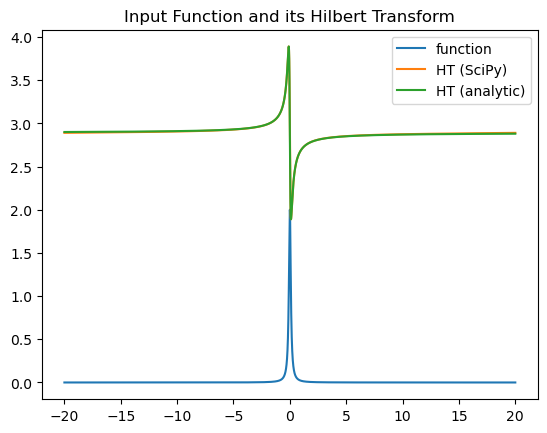

In [67]:
# generate nk for spatial KK stack

nb = 1.7
a = 2
pol = 'p'
length_MS = 20
#gam = 0.02
gam = 0.1

def eps(x, a, gam, nb):
    return nb**2 - a * gam / (x + 1j*gam)

xq = linspace(-200*gam, 200*gam, 100000)
func = np.zeros_like(xq)

for i, x in enumerate (xq):
    func[i] = np.imag(eps(x, a, gam, nb))

eq = interp1d(xq,func,kind='nearest')
Hx = hilbert(eq(xq))

plt.figure()
plt.plot(xq, func, label='function')
plt.plot(xq, -np.imag(Hx)+nb**2, label='HT (SciPy)')
plt.plot(xq, np.real(eps(xq, a, gam, nb)), label='HT (analytic)')
plt.title("Input Function and its Hilbert Transform")
plt.legend(loc='upper right')

xq2 = np.concatenate((linspace(0,10*gam,100), linspace(10*gam,50*gam,60) , linspace(50*gam,200*gam,40)))
xq2 = np.unique(np.concatenate((-xq2 , xq2)))
print(xq2.shape)

d_list = np.diff(xq2)
d_list[-1] = inf
d_list[0] = inf

eq2 = interp1d(xq,Hx,kind='nearest')

n_list = np.sqrt(-np.imag(eq2(xq2[:-1])) + nb**2 + 1j*np.real(eq2(xq2[:-1])))
print(n_list.shape)
print(d_list.shape)
#n_list[-1] = np.real(np.sqrt(eq(xq[-1])))
#n_list[0] = np.real(np.sqrt(eq(xq[0])))
n_list[-1] = nb
n_list[0] = nb


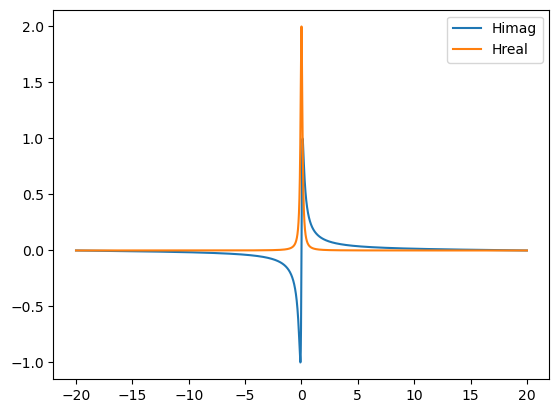

In [68]:
plt.plot(xq, np.imag(Hx), label='Himag')
plt.plot(xq, np.real(Hx), label='Hreal')
#plt.plot(xq, np.imag(H_inverse), '--', label='H_invimag')
#plt.plot(xq, np.real(H_inverse), '--', label='H_invreal')
plt.legend(loc='upper right')

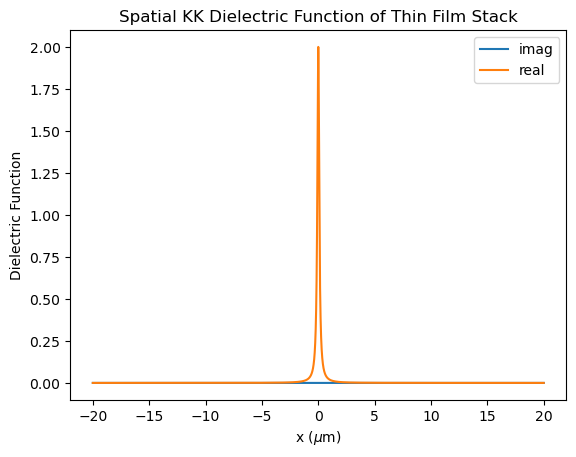

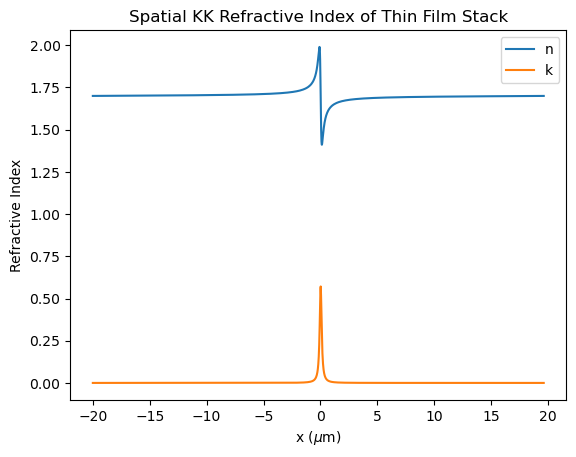

In [69]:
# plot dielectric function and refractive index

nkq = interp1d(xq,np.sqrt(Hx),kind='nearest')

plt.figure(1)
#plt.plot(x_list, lorentzian_imag(x_list, x0, a, gam))
#plt.plot(x_list, lorentzian_real(x_list, x0, a, gam))
plt.plot(xq, np.imag(eq(xq)), label='imag')
plt.plot(xq, np.real(eq(xq)), label='real')
plt.xlabel('x ($\mu$m)')
plt.ylabel('Dielectric Function')
plt.title('Spatial KK Dielectric Function of Thin Film Stack');
plt.legend(loc='upper right')

plt.figure(2)
#plt.plot(xq, np.real(nkq(xq)), label='n')
#plt.plot(xq, np.imag(nkq(xq)), label='k')
plt.plot(xq2[:-1], np.real(n_list), label='n')
plt.plot(xq2[:-1], np.imag(n_list), label='k')
plt.xlabel('x ($\mu$m)')
plt.ylabel('Refractive Index')
plt.title('Spatial KK Refractive Index of Thin Film Stack');
plt.legend(loc='upper right')

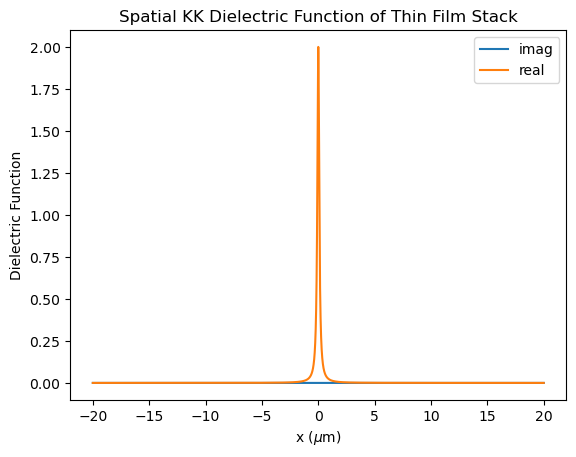

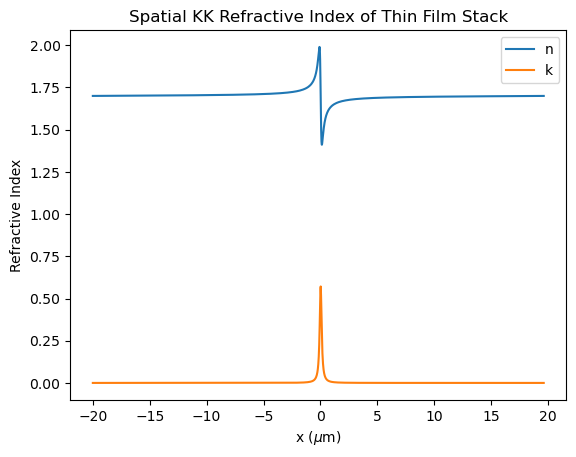

In [ ]:
# plot dielectric function and refractive index

nkq = interp1d(xq,np.sqrt(Hx),kind='nearest')

plt.figure(1)
#plt.plot(x_list, lorentzian_imag(x_list, x0, a, gam))
#plt.plot(x_list, lorentzian_real(x_list, x0, a, gam))
plt.plot(xq, np.imag(eq(xq)), label='imag')
plt.plot(xq, np.real(eq(xq)), label='real')
plt.xlabel('x ($\mu$m)')
plt.ylabel('Dielectric Function')
plt.title('Spatial KK Dielectric Function of Thin Film Stack');
plt.legend(loc='upper right')

plt.figure(2)
#plt.plot(xq, np.real(nkq(xq)), label='n')
#plt.plot(xq, np.imag(nkq(xq)), label='k')
plt.plot(xq2[:-1], np.real(n_list), label='n')
plt.plot(xq2[:-1], np.imag(n_list), label='k')
plt.xlabel('x ($\mu$m)')
plt.ylabel('Refractive Index')
plt.title('Spatial KK Refractive Index of Thin Film Stack');
plt.legend(loc='upper right')

In [70]:
# wavelength dependence calculation of RTA using coherent TMM function (coh_tmm and coh_tmm_reverse)

#theta_list = linspace(0,90,91) * degree
#lamb = 3  #nm
angle = 0
lambda_list = linspace(2, 5, 100)

T_list = []
R_list = []
for lamb in lambda_list:
    T_list.append(tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['T'])
    R_list.append(tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['R'])

T_reverse_list = []
R_reverse_list = []
for lamb in lambda_list:
    T_reverse_list.append(tmm.coh_tmm_reverse(pol, n_list, d_list, angle, lamb)['T'])
    R_reverse_list.append(tmm.coh_tmm_reverse(pol, n_list, d_list, angle, lamb)['R'])

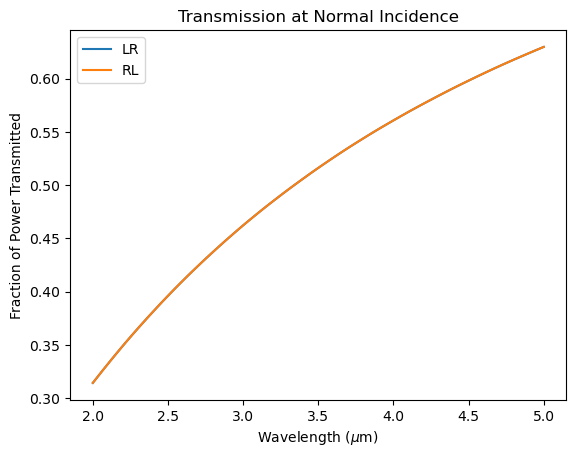

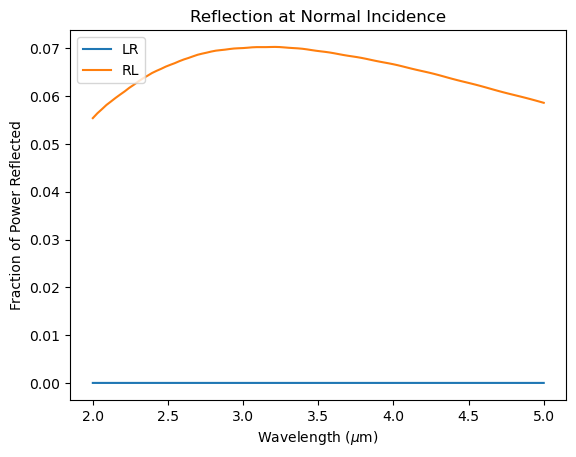

In [71]:
# plotting RTA forwards and backwards

plt.figure()
plt.plot(lambda_list,T_list, label='LR')
plt.plot(lambda_list,T_reverse_list, label='RL')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Fraction of Power Transmitted')
plt.title('Transmission at Normal Incidence');
plt.legend(loc='upper left')

plt.figure()
plt.plot(lambda_list,R_list, label='LR')
plt.plot(lambda_list,R_reverse_list, label='RL')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Fraction of Power Reflected')
plt.title('Reflection at Normal Incidence'); 
plt.legend(loc='upper left')

In [ ]:
def lorentzian(x):
    return 2 * 500**2 / ( 500**2 + ( x - 5000 )**2)
I = quad(lorentzian, 0, 10000)
print(I[0]/10000)

In [ ]:
#k_av = I[0]/10000
k_av = 0.1457
A_arr = []
T_arr = []

lambda_list = linspace(2000,5000,3000)

for lambda_vac in lambda_list:
    A_curr = 1-math.exp(-4*pi*k_av*10000/lambda_vac)
    A_arr.append(A_curr)
    T_arr.append(1-A_curr)

plt.figure()
plt.plot(lambda_list, T_arr)
